# 03 — SAR Preprocessing: Linear to dB Conversion

**Goal:** Convert Sentinel-1 RTC gamma-nought from linear scale to decibels.

### What does conversion to dB do?

RTC products from Planetary Computer are already radiometrically calibrated
to gamma-nought (γ0) in **linear power** scale. To compare across dates and
make the dynamic range human-readable, we convert to decibels:

- **γ0 dB** = 10 * log10(γ0 linear)

The dB scale compresses the huge dynamic range into interpretable values.
Typical ranges: urban ~ -5 to -8 dB, grassland ~ -12 to -15 dB, water ~ -20 dB.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

%matplotlib inline
plt.rcParams["figure.dpi"] = 120


def read_rtc_chip(item, asset_key, bbox_4326):
    """Read a Sentinel-1 RTC band windowed to a WGS84 bbox."""
    with rasterio.open(item.assets[asset_key].href) as src:
        native_bounds = transform_bounds("EPSG:4326", src.crs, *bbox_4326)
        window = from_bounds(*native_bounds, transform=src.transform)
        data = src.read(1, window=window).astype(np.float32)
    return data

In [2]:
# ---------------------------------------------------------------------------
# Load pre-fire VV chip from Planetary Computer RTC collection
# ---------------------------------------------------------------------------

AOI_BBOX = [-105.23, 39.915, -105.12, 39.98]

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search_pre = catalog.search(
    collections=["sentinel-1-rtc"],
    bbox=AOI_BBOX,
    datetime="2021-11-01/2021-11-30",
)
item_pre = sorted(search_pre.items(), key=lambda x: x.datetime)[0]
print(f"Using item: {item_pre.id}  ({item_pre.datetime.date()})")

vv_raw = read_rtc_chip(item_pre, "vv", AOI_BBOX)

print(f"Chip shape: {vv_raw.shape}")
print(f"γ0 linear range: {np.nanmin(vv_raw):.4f} -- {np.nanmax(vv_raw):.4f}")

Using item: S1A_IW_GRDH_1SDV_20211101T130958_20211101T131023_040378_04C92A_rtc  (2021-11-01)
Chip shape: (723, 941)
γ0 linear range: 0.0018 -- 242.8497


## Step 1: Convert to dB

RTC values are already gamma-nought in linear **power** scale, so the
conversion is simply:

**γ0 dB = 10 * log10(γ0 linear)**

No squaring needed (unlike raw GRD DN which is amplitude, not power).

In [3]:
# ---------------------------------------------------------------------------
# Calibration function: γ0 linear -> γ0 dB
# ---------------------------------------------------------------------------

def linear_to_db(linear_array):
    """Convert γ0 linear power to decibels.

    γ0_dB = 10 * log10(γ0_linear)

    Zeros/negatives are replaced with a tiny value to avoid -inf.
    """
    arr = linear_array.astype(np.float64)
    arr = np.where(arr > 0, arr, 1e-30)
    db = 10.0 * np.log10(arr)
    return db.astype(np.float32)


# Apply conversion
vv_db = linear_to_db(vv_raw)

print("After conversion to dB:")
print(f"  γ0 linear range: {np.nanmin(vv_raw):.4f} -- {np.nanmax(vv_raw):.4f}")
print(f"  γ0 dB range:     {np.nanmin(vv_db):.1f} -- {np.nanmax(vv_db):.1f}")
print(f"  γ0 dB mean:      {np.nanmean(vv_db):.1f}")

After conversion to dB:
  γ0 linear range: 0.0018 -- 242.8497
  γ0 dB range:     -27.3 -- 23.9
  γ0 dB mean:      -13.3


## Compare raw DN vs sigma0 linear vs sigma0 dB

Three panels showing the same data in different representations:
- **Raw DN**: linear amplitude, huge dynamic range
- **sigma0 linear**: squared, even more skewed
- **sigma0 dB**: compressed, easier to interpret visually

NameError: name 'vv_linear' is not defined

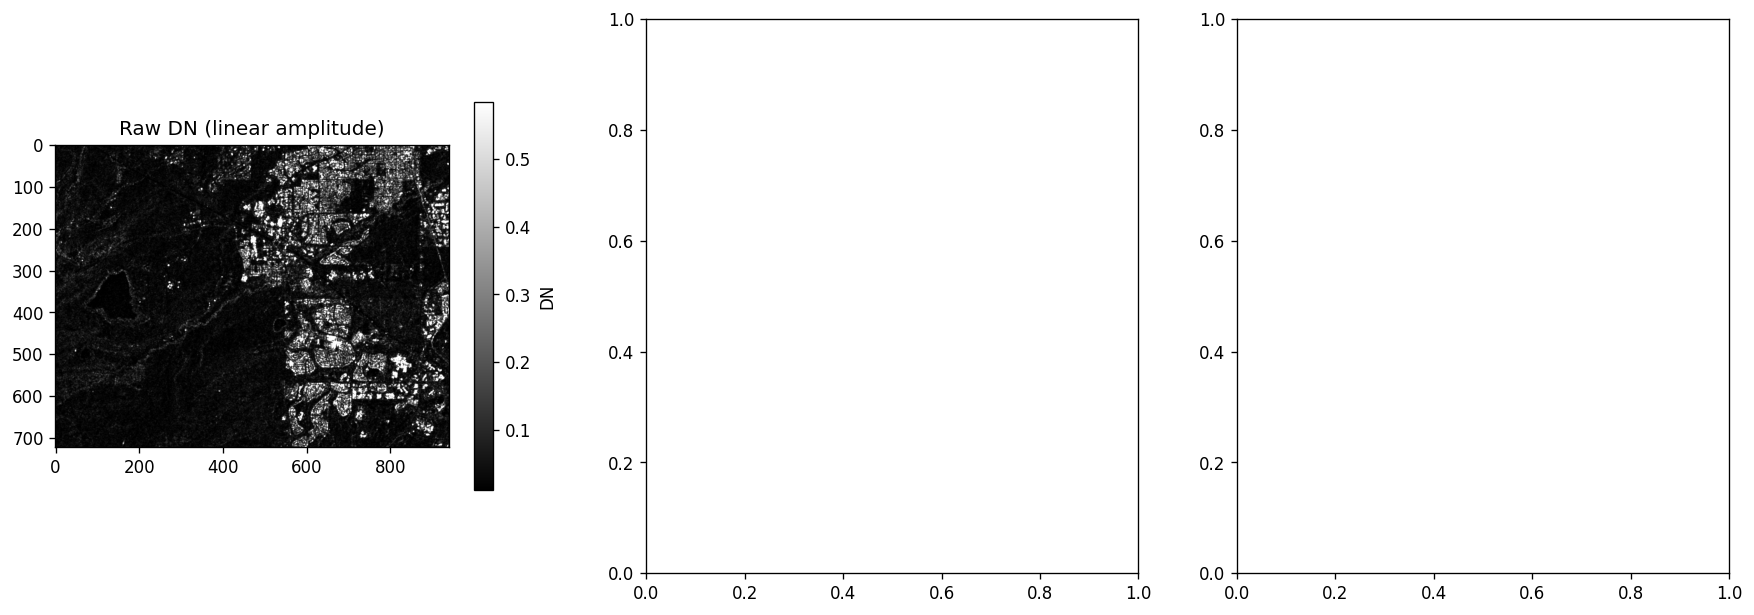

In [4]:
# ---------------------------------------------------------------------------
# 1x3 comparison plot
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Raw DN with percentile stretch
p2, p98 = np.nanpercentile(vv_raw, [2, 98])
im0 = axes[0].imshow(vv_raw, cmap="gray", vmin=p2, vmax=p98)
axes[0].set_title("Raw DN (linear amplitude)")
plt.colorbar(im0, ax=axes[0], shrink=0.7, label="DN")

# sigma0 linear with percentile stretch
p2l, p98l = np.nanpercentile(vv_linear, [2, 98])
im1 = axes[1].imshow(vv_linear, cmap="gray", vmin=p2l, vmax=p98l)
axes[1].set_title("sigma0 linear (DN^2)")
plt.colorbar(im1, ax=axes[1], shrink=0.7, label="power")

# sigma0 dB -- fixed range so the scale is interpretable
im2 = axes[2].imshow(vv_db, cmap="gray", vmin=-20, vmax=0)
axes[2].set_title("sigma0 dB (10 * log10)")
plt.colorbar(im2, ax=axes[2], shrink=0.7, label="dB")

for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.suptitle(f"Sentinel-1 VV -- Three Representations ({item_pre.datetime.date()})",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Measure backscatter by land-cover class

We define sample ROIs (regions of interest) using pixel row/column ranges
for three land-cover types. These are approximate -- the point is to see
that different surfaces produce different backscatter levels:

- **Urban** (buildings + pavement): typically -5 to -8 dB
- **Burned / bare ground**: lower return
- **Grassland / open field**: typically -12 to -15 dB

In [ ]:
# ---------------------------------------------------------------------------
# Define sample ROIs by pixel coordinates
# These are rough regions -- adjust if the chip extent changes.
# The goal is to show that backscatter varies by land cover.
# ---------------------------------------------------------------------------

rows, cols = vv_db.shape

# Define ROIs as (row_start, row_end, col_start, col_end)
# We pick regions from different quadrants of the chip
rois = {
    "urban":     (int(rows * 0.3), int(rows * 0.4), int(cols * 0.4), int(cols * 0.6)),
    "burned":    (int(rows * 0.5), int(rows * 0.6), int(cols * 0.3), int(cols * 0.5)),
    "grassland": (int(rows * 0.7), int(rows * 0.8), int(cols * 0.6), int(cols * 0.8)),
}

print(f"Chip size: {rows} rows x {cols} cols\n")
print(f"{'Class':<12} {'ROI (r0:r1, c0:c1)':<25} {'Mean dB':>8} {'Std dB':>8} {'Pixels':>7}")
print("-" * 65)

for name, (r0, r1, c0, c1) in rois.items():
    patch = vv_db[r0:r1, c0:c1]
    mean_db = np.nanmean(patch)
    std_db = np.nanstd(patch)
    n_pix = patch.size
    print(f"{name:<12} ({r0}:{r1}, {c0}:{c1}){'':<7} {mean_db:>8.2f} {std_db:>8.2f} {n_pix:>7,}")

print("\nNote: These are pre-fire values.")
print("Urban areas should show higher (less negative) backscatter than grassland.")
print("Typical ranges: urban ~ -5 to -8 dB, grassland ~ -12 to -15 dB.")

# Visualize the ROIs on the dB image
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(vv_db, cmap="gray", vmin=-20, vmax=0)

colors = {"urban": "red", "burned": "orange", "grassland": "lime"}
for name, (r0, r1, c0, c1) in rois.items():
    rect = plt.Rectangle((c0, r0), c1 - c0, r1 - r0,
                          linewidth=2, edgecolor=colors[name],
                          facecolor="none", label=name)
    ax.add_patch(rect)

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Sample ROIs on sigma0 dB image")
plt.tight_layout()
plt.show()